In [116]:
import numpy as np
import matplotlib.pyplot as plt
import math 

In [117]:
lambd = 3.5 / 100
N = 14
l = 1.6 / 100
d = 2 / 100
a = 23 / 1000

k = (2 * math.pi) / lambd
v = 1
lambdhv = lambd / (np.sqrt(1 - (lambd / (2 * a))))

In [118]:
F1h = []
FC = []
FH = []
steps = []
max_x_FH = []
max_y_FH = []
min_x_FH = []
min_y_FH = []

In [119]:
for teta in np.arange(-np.pi / 2, np.pi / 2, 0.00001):
    mn1 = math.cos(((np.pi / 2)) * np.sin(teta)) / np.cos(teta)
    mn2 = (np.sin((N / 2) * (k * d * np.sin(teta) - ((2 * np.pi ) / lambdhv) * d + v * np.pi))) / (N * np.sin((1 / 2) * (k * d * np.sin(teta) - ((2 * np.pi ) / lambdhv) * d + v * np.pi)))
    mn3 = mn1 * mn2

    F1h.append(mn1)
    FC.append(mn2)
    FH.append(mn3)

    steps.append(math.degrees(teta))


for i in range(1, len(FH) - 1):
    if FH[i] > 0 and FH[i + 1] < 0 or FH[i] < 0 and FH[i + 1] > 0:
        min_x_FH.append(steps[i])
        min_y_FH.append(0)

for i in range(1, len(FH) - 1):
    if FH[i] > FH[i - 1] and FH[i] > FH[i + 1]:
        max_x_FH.append(steps[i])
        max_y_FH.append(FH[i])

for i in range(1, len(FH) - 1):
    if 0.707 < FH[i] < 0.708:
        y707 = FH[i]
        x707 = steps[i]

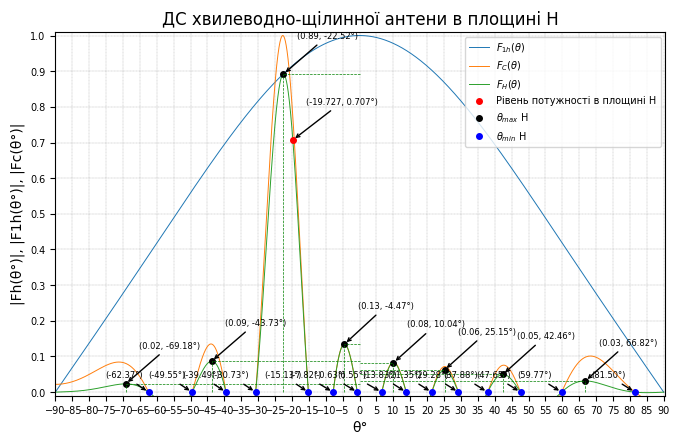

In [120]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС хвилеводно-щілинної антени в площині H")
ax.plot(steps, F1h, linewidth=0.7, label="$ F_{1h}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FH, linewidth=0.7, label="$ F_{H}(θ) $")
ax.plot(x707, y707, 'ro', markersize=4, label="Рівень потужності в площині H")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
ax.plot(max_x_FH, max_y_FH, "o", markersize=4, color="black", label="$ \\theta_{max} $ H")
ax.plot(min_x_FH, min_y_FH, "o", markersize=4, color="blue", label="$ \\theta_{min} $ H")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fh(θ' + '\u00b0' + ')|, |F1h(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(np.arange(-100, 100, 5), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(-90.05, 90.5)


for i in range(len(max_x_FH)):
    plt.vlines(x=max_x_FH[i], ymin=0, ymax=max_y_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH[i], xmin=0, xmax=max_x_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH[i]:.2f}, {max_x_FH[i]:.2f}\u00b0)',
                 xy=(max_x_FH[i], max_y_FH[i]),
                 xytext=(max_x_FH[i]+4, max_y_FH[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH)):
    plt.annotate(f'({min_x_FH[i]:.2f}\u00b0)',
                 xy=(min_x_FH[i], min_y_FH[i]),
                 xytext=(min_x_FH[i]-13, min_y_FH[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС у площині Н, лабораторна 4.jpg", dpi=600)
plt.show()

In [121]:

print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in min_x_FH:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in max_x_FH:
    print(f"| {m} |{i:.2f}| {max_y_FH[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |-62.37|  0  |
| 2 |-49.55|  0  |
| 3 |-39.49|  0  |
| 4 |-30.73|  0  |
| 5 |-15.13|  0  |
| 6 |-7.82|  0  |
| 7 |-0.63|  0  |
| 8 |6.55|  0  |
| 9 |13.83|  0  |
| 10 |21.35|  0  |
| 11 |29.28|  0  |
| 12 |37.88|  0  |
| 13 |47.65|  0  |
| 14 |59.77|  0  |
| 15 |81.50|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |-69.18| 0.02|
| 2 |-43.73| 0.09|
| 3 |-22.52| 0.89|
| 4 |-4.47| 0.13|
| 5 |10.04| 0.08|
| 6 |25.15| 0.06|
| 7 |42.46| 0.05|
| 8 |66.82| 0.03|
-----------------


In [122]:
SGP1 = 2 * np.asin(lambd / (d * N))
print("Ширина головної пелюстки = " + str(round(SGP1, 2)) + '\u00b0')

Ширина головної пелюстки = 0.25°


In [123]:
FE = []
max_x_FE = []
max_y_FE = []
min_x_FE = []
min_y_FE = []

In [124]:
for teta in np.arange(-np.pi / 2, np.pi / 2, 0.00001):
    fe = (np.sin((N / 2) * (k * d * np.sin(teta) - ((2 * np.pi) / lambdhv) * d))) / (N * np.sin((1 / 2) * (k * d * np.sin(teta) - ((2 * np.pi) / lambdhv) * d)))
    FE.append(fe)


for i in range(1, len(FH) - 1):
    if FE[i] > 0 and FE[i + 1] < 0 or FE[i] < 0 and FE[i + 1] > 0:
        min_x_FE.append(steps[i])
        min_y_FE.append(0)

for i in range(1, len(FE) - 1):
    if FE[i] > FE[i - 1] and FE[i] > FE[i + 1]:
        max_x_FE.append(steps[i])
        max_y_FE.append(FE[i])

for i in range(1, len(FE) - 1):
    if 0.707 < FE[i] < 0.708:
        y707 = FE[i]
        x707 = steps[i]


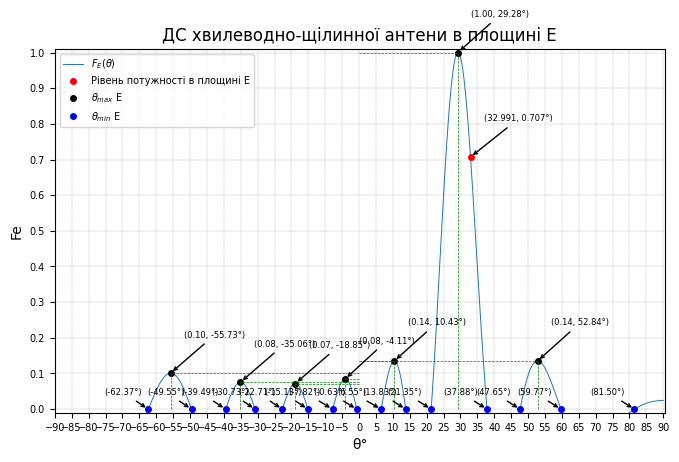

In [125]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС хвилеводно-щілинної антени в площині E")
ax.plot(steps, FE, linewidth=0.7, label="$ F_{E}(θ) $")
ax.plot(x707, y707, 'ro', markersize=4, label="Рівень потужності в площині E")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
ax.plot(max_x_FE, max_y_FE, "o", markersize=4, color="black", label="$ \\theta_{max} $ E")
ax.plot(min_x_FE, min_y_FE, "o", markersize=4, color="blue", label="$ \\theta_{min} $ E")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('Fe', fontsize=10)
plt.xticks(np.arange(-100, 100, 5), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(-90.05, 90.5)


for i in range(len(max_x_FE)):
    plt.vlines(x=max_x_FE[i], ymin=0, ymax=max_y_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FE[i], xmin=0, xmax=max_x_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FE[i]:.2f}, {max_x_FE[i]:.2f}\u00b0)',
                 xy=(max_x_FE[i], max_y_FE[i]),
                 xytext=(max_x_FE[i]+4, max_y_FE[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FE)):
    plt.annotate(f'({min_x_FE[i]:.2f}\u00b0)',
                 xy=(min_x_FE[i], min_y_FE[i]),
                 xytext=(min_x_FE[i]-13, min_y_FE[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper left", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС у площині E, лабораторна 4.jpg", dpi=600)
plt.show()

In [126]:

print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in min_x_FE:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in max_x_FE:
    print(f"| {m} |{i:.2f}| {max_y_FE[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |-62.37|  0  |
| 2 |-49.55|  0  |
| 3 |-39.49|  0  |
| 4 |-30.73|  0  |
| 5 |-22.71|  0  |
| 6 |-15.13|  0  |
| 7 |-7.82|  0  |
| 8 |-0.63|  0  |
| 9 |6.55|  0  |
| 10 |13.83|  0  |
| 11 |21.35|  0  |
| 12 |37.88|  0  |
| 13 |47.65|  0  |
| 14 |59.77|  0  |
| 15 |81.50|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |-55.73| 0.10|
| 2 |-35.06| 0.08|
| 3 |-18.85| 0.07|
| 4 |-4.11| 0.08|
| 5 |10.43| 0.14|
| 6 |29.28| 1.00|
| 7 |52.84| 0.14|
-----------------
